# 01 - Exploratory Data Analysis (EDA)

## AI-Powered Runway FOD Detection & Safety Alert System

### Objective

In this notebook, we will understand the FOD-A dataset before model training.

We will analyze:

- Dataset size
- Dataset columns
- Missing values
- Duplicate records
- Image dimensions
- Train/validation and test split
- FOD classes
- Weather conditions
- Light conditions
- Number of objects per image
- Basic relationships between FOD classes, weather and light

This notebook is for understanding the dataset.

Detailed bounding-box analysis will be performed in the next notebook:
`02_Annotation_Analysis.ipynb`.


## 1. Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load the Processed Dataset

In [2]:
# Get the project root directory
PROJECT_ROOT = Path.cwd().parent

# Path of the processed annotation file
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "fod_annotations.csv"

# Load the dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)


Dataset loaded successfully.
Dataset shape: (34472, 25)


## 3. View the Dataset

In [3]:
# Display first 5 rows
df.head()


,image_id,filename,image_path,annotation_path,split,width,height,class_name,xmin,ymin,...,pose,track_id,keyframe,weather_label,light_label,image_exists,x_center,y_center,box_width,box_height
0,0,000000.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2219,104.2833,...,Unspecified,0,True,Wet,Dim,True,0.482771,0.421051,0.044062,0.14688
1,1,000001.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2422,104.7611,...,Unspecified,0,False,Wet,Dim,True,0.482841,0.422644,0.044068,0.14688
2,2,000002.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2641,105.2389,...,Unspecified,0,False,Wet,Dim,True,0.482911,0.424236,0.044062,0.14688
3,3,000003.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2844,105.7167,...,Unspecified,0,False,Wet,Dim,True,0.482979,0.425829,0.044063,0.14688
4,4,000004.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.3047,106.1945,...,Unspecified,0,False,Wet,Dim,True,0.483047,0.427417,0.044062,0.14687


In [4]:
# Display last 5 rows
df.tail()


,image_id,filename,image_path,annotation_path,split,width,height,class_name,xmin,ymin,...,pose,track_id,keyframe,weather_label,light_label,image_exists,x_center,y_center,box_width,box_height
34467,33788,033788.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,unassigned,300,300,Wrench,29.0028,127.9203,...,Unspecified,0,True,Dry,Dim,True,0.548338,0.499346,0.903324,0.145891
34468,33789,033789.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,unassigned,300,300,Wrench,33.9583,127.3891,...,Unspecified,0,False,Dry,Dim,True,0.556597,0.497518,0.886806,0.145776
34469,33790,033790.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,unassigned,300,300,Wrench,38.9167,126.8594,...,Unspecified,0,True,Dry,Dim,True,0.564861,0.495693,0.870278,0.145656
34470,33791,033791.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,unassigned,300,300,Wrench,40.7778,126.4781,...,Unspecified,0,False,Dry,Dim,True,0.567963,0.493943,0.864074,0.144698
34471,33792,033792.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,unassigned,300,300,Wrench,42.6389,126.0984,...,Unspecified,0,True,Dry,Dim,True,0.571065,0.492195,0.857870,0.143735


## 4. Dataset Information

In [5]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 34472
Number of columns: 25


In [6]:
# Check column names
print("Column names:")
print(df.columns.tolist())


Column names:
['image_id', 'filename', 'image_path', 'annotation_path', 'split', 'width', 'height', 'class_name', 'xmin', 'ymin', 'xmax', 'ymax', 'occluded', 'truncated', 'difficult', 'pose', 'track_id', 'keyframe', 'weather_label', 'light_label', 'image_exists', 'x_center', 'y_center', 'box_width', 'box_height']


In [7]:
# Check data types and non-null values
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 34472 entries, 0 to 34471
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   image_id         34472 non-null  int64  
 1   filename         34472 non-null  str    
 2   image_path       34472 non-null  str    
 3   annotation_path  34472 non-null  str    
 4   split            34472 non-null  str    
 5   width            34472 non-null  int64  
 6   height           34472 non-null  int64  
 7   class_name       34472 non-null  str    
 8   xmin             34472 non-null  float64
 9   ymin             34472 non-null  float64
 10  xmax             34472 non-null  float64
 11  ymax             34472 non-null  float64
 12  occluded         34472 non-null  int64  
 13  truncated        34472 non-null  int64  
 14  difficult        34472 non-null  int64  
 15  pose             34472 non-null  str    
 16  track_id         34472 non-null  int64  
 17  keyframe         34472 

## 5. Statistical Summary

In [8]:
# Statistical summary of numeric columns
df.describe()


,image_id,width,height,xmin,ymin,xmax,ymax,occluded,truncated,difficult,track_id,x_center,y_center,box_width,box_height
count,34472.000000,34472.0,34472.0,34472.000000,34472.000000,34472.000000,34472.000000,34472.0,34472.0,34472.0,34472.000000,34472.000000,34472.000000,34472.000000,34472.000000
mean,16737.575859,300.0,300.0,118.423810,108.146556,181.240286,190.470200,0.0,0.0,0.0,0.019697,0.499440,0.497695,0.209388,0.274412
std,9723.273792,0.0,0.0,50.236730,63.578142,49.049912,65.798418,0.0,0.0,0.0,0.138959,0.140682,0.188319,0.174303,0.210190
min,0.000000,300.0,300.0,0.000000,0.000000,5.453100,4.136800,0.0,0.0,0.0,0.000000,0.009088,0.007653,0.011242,0.011131
25%,8565.750000,300.0,300.0,92.205025,63.090550,154.552325,150.313550,0.0,0.0,0.0,0.000000,0.445406,0.388803,0.077320,0.107855
50%,16556.500000,300.0,300.0,124.564000,109.450000,176.654700,189.217350,0.0,0.0,0.0,0.000000,0.502887,0.502729,0.161492,0.216074
75%,25174.250000,300.0,300.0,148.283625,146.531400,206.006225,237.627075,0.0,0.0,0.0,0.000000,0.563482,0.598830,0.290778,0.398540
max,33792.000000,300.0,300.0,293.281300,294.355300,300.000000,300.000000,0.0,0.0,0.0,1.000000,0.988802,0.989852,1.000000,1.000000


## 6. Missing Values

In [9]:
# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)


Missing values:
image_id           0
filename           0
image_path         0
annotation_path    0
split              0
width              0
height             0
class_name         0
xmin               0
ymin               0
xmax               0
ymax               0
occluded           0
truncated          0
difficult          0
pose               0
track_id           0
keyframe           0
weather_label      0
light_label        0
image_exists       0
x_center           0
y_center           0
box_width          0
box_height         0
dtype: int64


In [10]:
# Show columns that contain missing values
missing_values[missing_values > 0]


Series([], dtype: int64)

## 7. Duplicate Records

In [11]:
# Count completely duplicated rows
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)


Number of duplicate rows: 0


## 8. Unique Images and FOD Classes

In [12]:
# Number of unique images
unique_images = df["image_id"].nunique()

# Number of unique FOD classes
unique_classes = df["class_name"].nunique()

print("Unique images:", unique_images)
print("Unique FOD classes:", unique_classes)


Unique images: 33793
Unique FOD classes: 31


## 9. Image Dimensions

In [13]:
# Check image width and height
print("Unique image widths:")
print(df["width"].unique())

print("\nUnique image heights:")
print(df["height"].unique())


Unique image widths:
[300]

Unique image heights:
[300]


In [14]:
# Count images by width and height
image_dimensions = df[["image_id", "width", "height"]].drop_duplicates()

print("Image dimension distribution:")
print(
    image_dimensions.groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
)


Image dimension distribution:
width  height
300    300       33793
dtype: int64


## 10. Dataset Split

In [15]:
# Count annotation rows in each split
split_counts = df["split"].value_counts()

print(split_counts)


split
trainval      25789
test           8613
unassigned       70
Name: count, dtype: int64


In [16]:
# Count unique images in each split
split_images = df.groupby("split")["image_id"].nunique()

print("Unique images in each split:")
print(split_images)


Unique images in each split:
split
test           8429
trainval      25294
unassigned       70
Name: image_id, dtype: int64


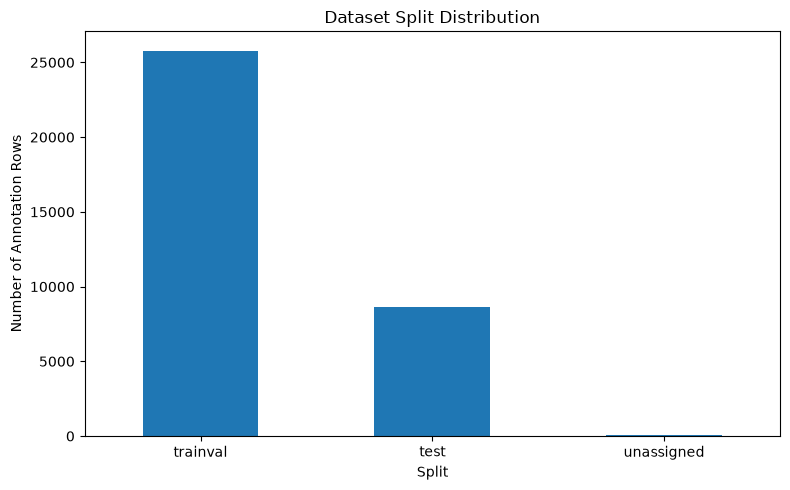

In [17]:
# Plot the split distribution
plt.figure(figsize=(8, 5))

split_counts.plot(kind="bar")

plt.title("Dataset Split Distribution")
plt.xlabel("Split")
plt.ylabel("Number of Annotation Rows")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. FOD Class Distribution

In [18]:
# Count annotations for each FOD class
class_counts = df["class_name"].value_counts()

print("FOD class distribution:")
print(class_counts)


FOD class distribution:
class_name
Bolt                3300
Pliers              2884
Wrench              2568
Washer              2139
Wire                2138
PlasticPart         2008
LuggageTag          1686
Cutter              1352
Label               1310
Nut                 1303
Nail                1193
Battery             1059
BoltWasher          1017
MetalPart            970
PaintChip            968
SodaCan              950
ClampPart            917
Screwdriver          811
Hammer               760
LuggagePart          738
Rock                 662
FuelCap              548
AdjustableClamp      544
BoltNutSet           514
Pen                  483
AdjustableWrench     472
MetalSheet           394
Hose                 294
Wood                 206
Screw                157
Tape                 127
Name: count, dtype: int64


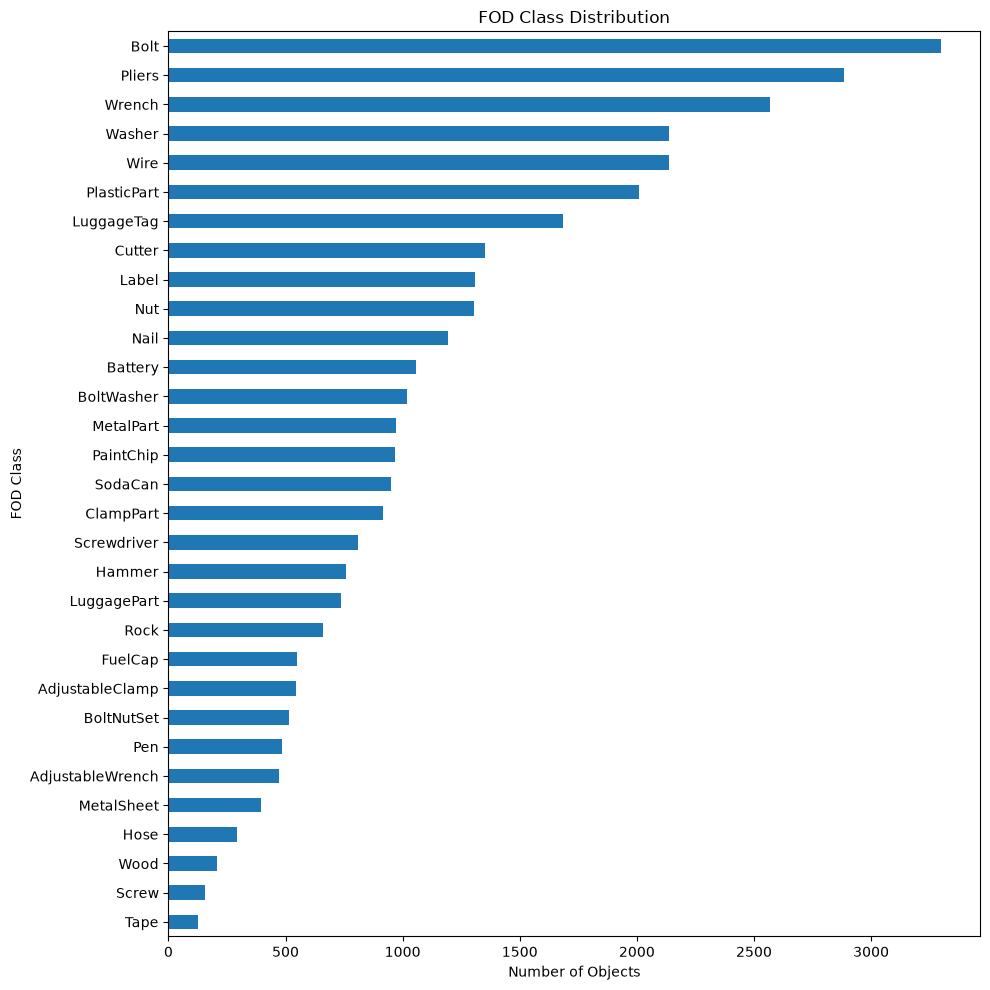

In [19]:
# Plot FOD class distribution
plt.figure(figsize=(10, 10))

class_counts.sort_values().plot(kind="barh")

plt.title("FOD Class Distribution")
plt.xlabel("Number of Objects")
plt.ylabel("FOD Class")

plt.tight_layout()
plt.show()


## 12. Most Common FOD Classes

In [20]:
# Top 10 most common FOD classes
top_classes = class_counts.head(10)

print("Top 10 FOD classes:")
print(top_classes)


Top 10 FOD classes:
class_name
Bolt           3300
Pliers         2884
Wrench         2568
Washer         2139
Wire           2138
PlasticPart    2008
LuggageTag     1686
Cutter         1352
Label          1310
Nut            1303
Name: count, dtype: int64


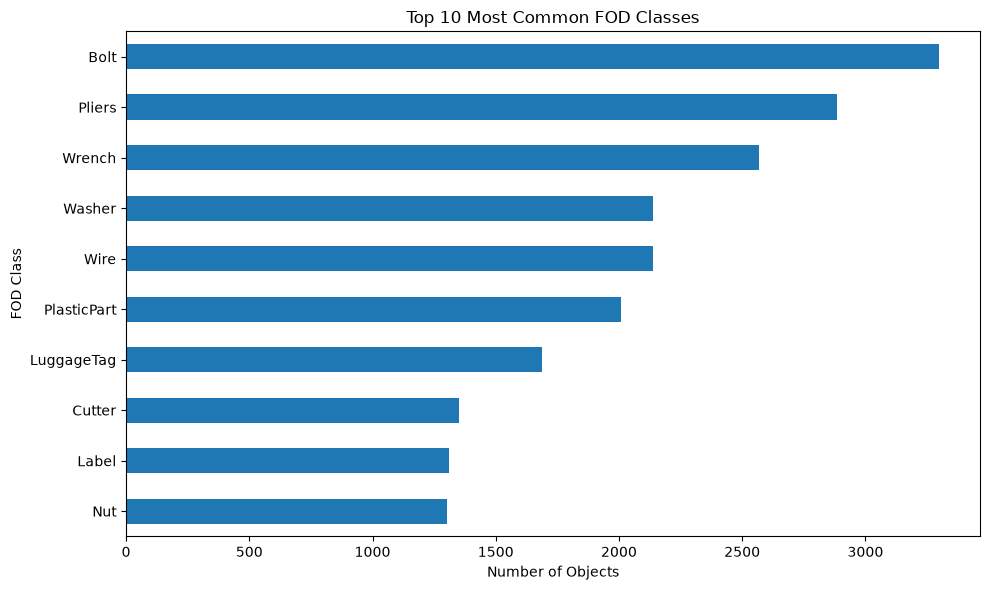

In [21]:
plt.figure(figsize=(10, 6))

top_classes.sort_values().plot(kind="barh")

plt.title("Top 10 Most Common FOD Classes")
plt.xlabel("Number of Objects")
plt.ylabel("FOD Class")

plt.tight_layout()
plt.show()


## 13. Rare FOD Classes

In [22]:
# Show classes with fewer than 100 annotations
rare_classes = class_counts[class_counts < 100]

print("Rare FOD classes:")
print(rare_classes)


Rare FOD classes:
Series([], Name: count, dtype: int64)


## 14. Objects Per Image

In [23]:
# Count how many FOD objects are present in each image
objects_per_image = df.groupby("image_id").size()

print("Average objects per image:", objects_per_image.mean())
print("Median objects per image:", objects_per_image.median())
print("Maximum objects in one image:", objects_per_image.max())


Average objects per image: 1.0200929186517917
Median objects per image: 1.0
Maximum objects in one image: 2


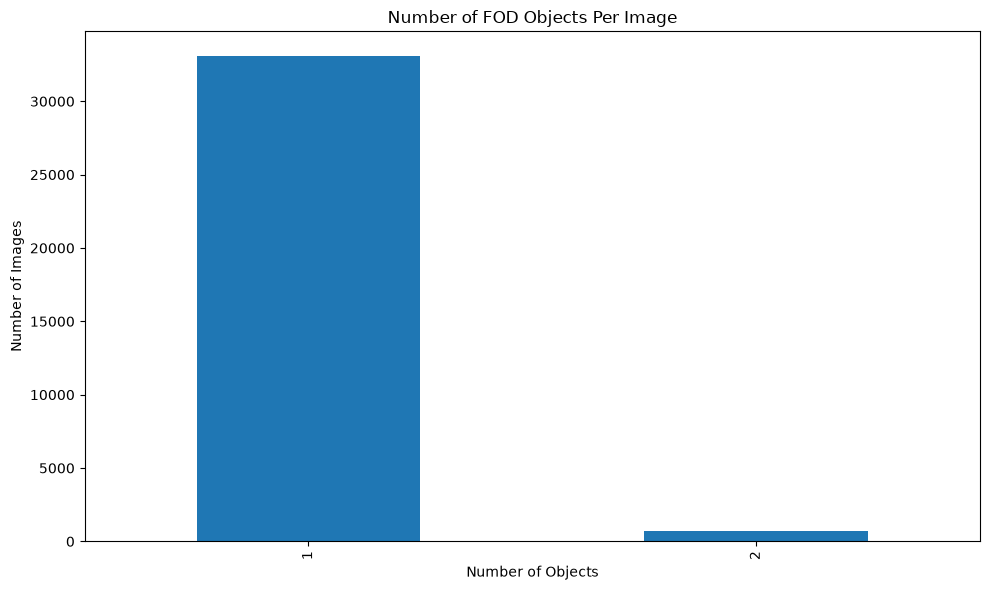

In [24]:
# Distribution of objects per image
plt.figure(figsize=(10, 6))

objects_per_image.value_counts().sort_index().plot(kind="bar")

plt.title("Number of FOD Objects Per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()


## 15. Weather Distribution

In [25]:
# Count objects under each weather condition
weather_counts = df["weather_label"].value_counts()

print("Weather distribution:")
print(weather_counts)


Weather distribution:
weather_label
Dry    27256
Wet     7216
Name: count, dtype: int64


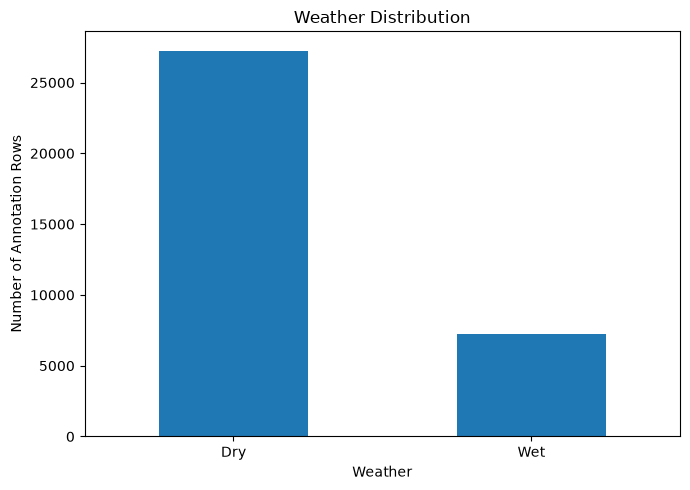

In [26]:
plt.figure(figsize=(7, 5))

weather_counts.plot(kind="bar")

plt.title("Weather Distribution")
plt.xlabel("Weather")
plt.ylabel("Number of Annotation Rows")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 16. Light Condition Distribution

In [27]:
# Count objects under each light condition
light_counts = df["light_label"].value_counts()

print("Light condition distribution:")
print(light_counts)


Light condition distribution:
light_label
Bright    17621
Dim       12464
Dark       4387
Name: count, dtype: int64


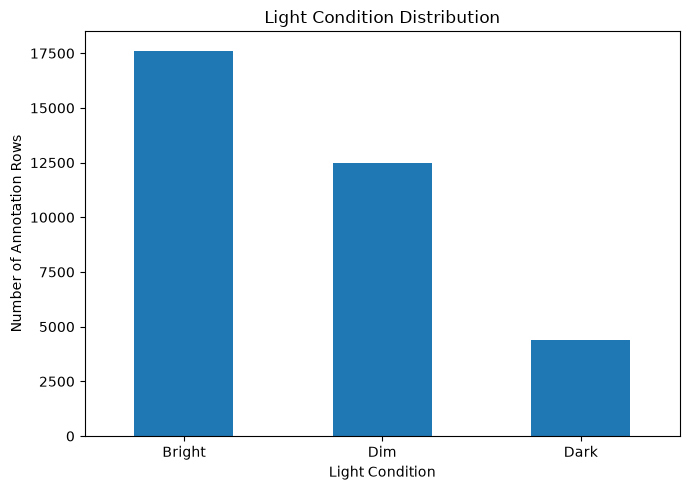

In [28]:
plt.figure(figsize=(7, 5))

light_counts.plot(kind="bar")

plt.title("Light Condition Distribution")
plt.xlabel("Light Condition")
plt.ylabel("Number of Annotation Rows")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 17. FOD Classes by Weather

In [29]:
# Count FOD classes for each weather condition
weather_class_table = pd.crosstab(
    df["class_name"],
    df["weather_label"]
)

weather_class_table.head(10)


weather_label,Dry,Wet
class_name,,
AdjustableClamp,544,0
AdjustableWrench,472,0
Battery,359,700
Bolt,3300,0
BoltNutSet,514,0
BoltWasher,276,741
ClampPart,799,118
Cutter,514,838
FuelCap,342,206


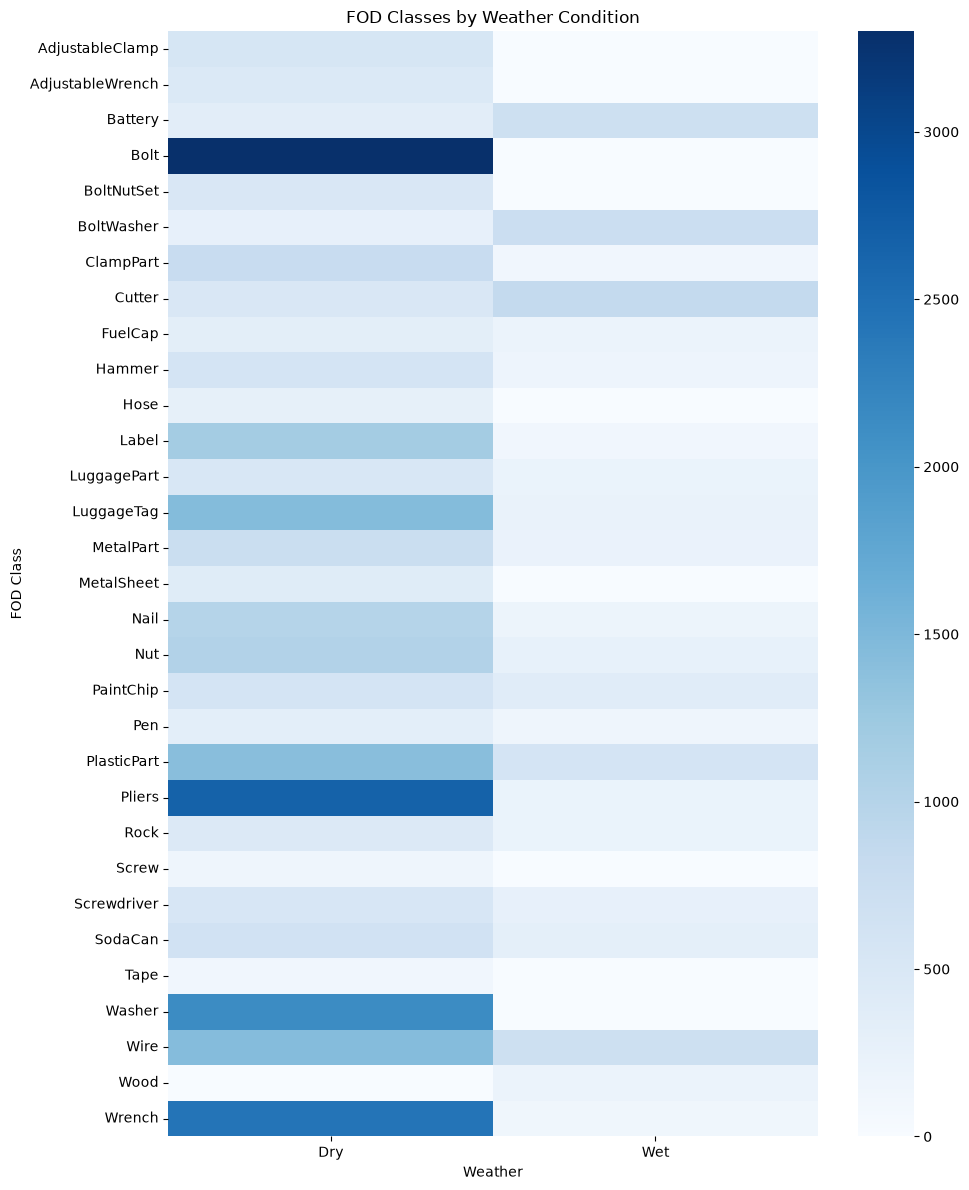

In [30]:
# Heatmap of FOD classes and weather conditions
plt.figure(figsize=(10, 12))

sns.heatmap(
    weather_class_table,
    annot=False,
    cmap="Blues"
)

plt.title("FOD Classes by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("FOD Class")

plt.tight_layout()
plt.show()


## 18. FOD Classes by Light Condition

In [31]:
# Count FOD classes for each light condition
light_class_table = pd.crosstab(
    df["class_name"],
    df["light_label"]
)

light_class_table.head(10)


light_label,Bright,Dark,Dim
class_name,,,
AdjustableClamp,544,0,0
AdjustableWrench,472,0,0
Battery,0,173,886
Bolt,3118,182,0
BoltNutSet,514,0,0
BoltWasher,134,0,883
ClampPart,129,328,460
Cutter,150,188,1014
FuelCap,119,0,429


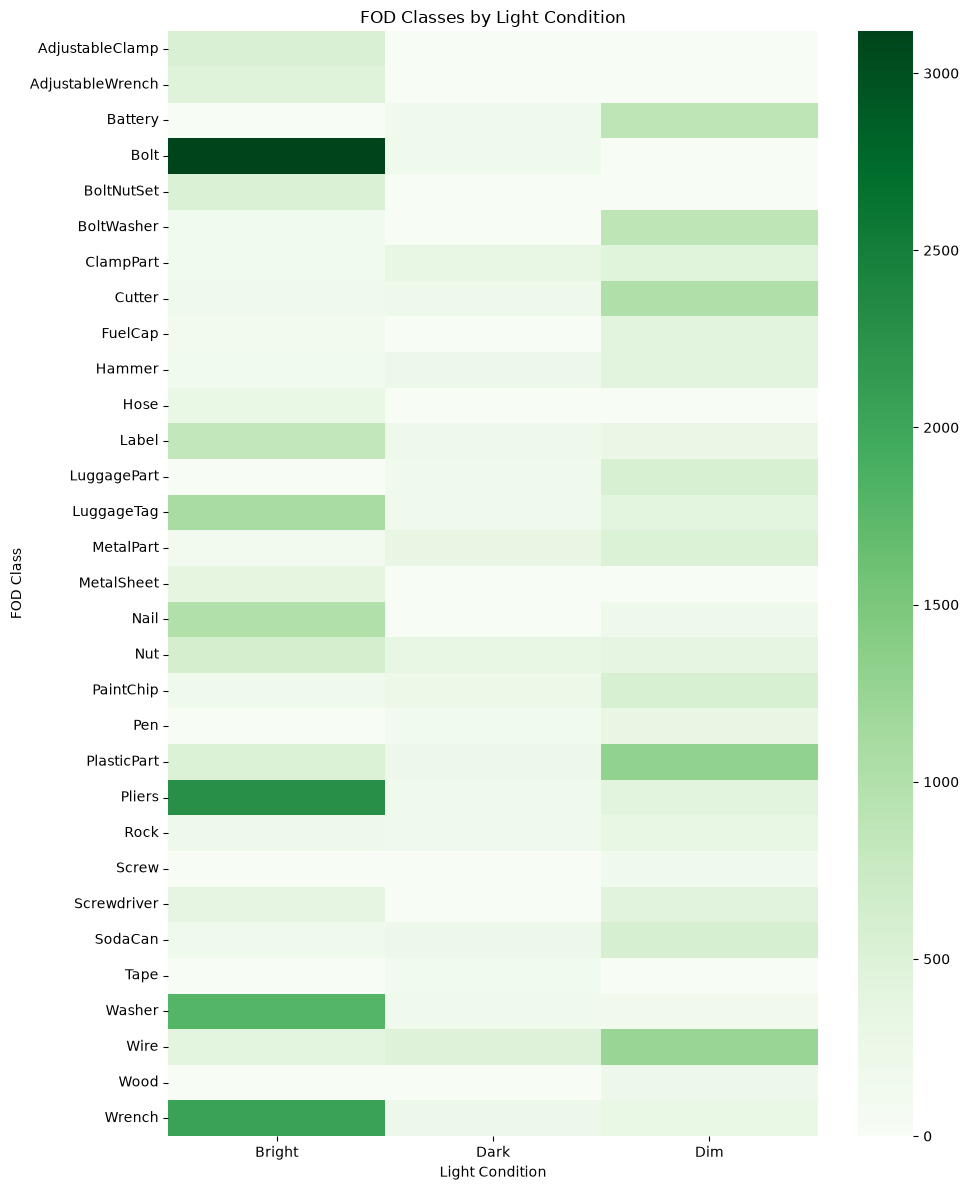

In [32]:
# Heatmap of FOD classes and light conditions
plt.figure(figsize=(10, 12))

sns.heatmap(
    light_class_table,
    annot=False,
    cmap="Greens"
)

plt.title("FOD Classes by Light Condition")
plt.xlabel("Light Condition")
plt.ylabel("FOD Class")

plt.tight_layout()
plt.show()


## 19. Occluded Objects

In [33]:
# Count occlusion values
print(df["occluded"].value_counts(dropna=False))


occluded
0    34472
Name: count, dtype: int64


## 20. Truncated Objects

In [34]:
# Count truncated values
print(df["truncated"].value_counts(dropna=False))


truncated
0    34472
Name: count, dtype: int64


## 21. Difficult Objects

In [35]:
# Count difficult values
print(df["difficult"].value_counts(dropna=False))


difficult
0    34472
Name: count, dtype: int64


## 22. Basic Bounding Box Summary

In [36]:
# Basic summary of bounding box dimensions
print("Bounding box width:")
print(df["box_width"].describe())

print("\nBounding box height:")
print(df["box_height"].describe())


Bounding box width:
count    34472.000000
mean         0.209388
std          0.174303
min          0.011242
25%          0.077320
50%          0.161492
75%          0.290778
max          1.000000
Name: box_width, dtype: float64

Bounding box height:
count    34472.000000
mean         0.274412
std          0.210190
min          0.011131
25%          0.107855
50%          0.216074
75%          0.398540
max          1.000000
Name: box_height, dtype: float64


## 23. EDA Summary

At the end of this notebook, we should understand:

1. How large the dataset is.
2. How many FOD classes are present.
3. How the dataset is divided into train/validation and test data.
4. Which FOD classes are common and which are rare.
5. How many objects are usually present in an image.
6. How weather conditions are distributed.
7. How light conditions are distributed.
8. Whether the dataset contains missing or duplicate records.
9. Basic image dimensions and annotation metadata.
10. Basic bounding-box information.

Detailed bounding-box location, size, aspect-ratio, class imbalance analysis,
and visual inspection of annotations will be covered in:

`02_Annotation_Analysis.ipynb`
